<a href="https://colab.research.google.com/github/3R3NY34G3R/CPE313---Advanced-Machine-Learning-and-Deep-Learning/blob/main/Hands_on_Activity_5_2_Topic_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity 5.2 Topic Modeling

#### Objective(s):

This activity aims to introduce how to use LDA for topic modeling

#### Intended Learning Outcomes (ILOs):
* Demonstrate how to preprocess words in the dataset.
* Demonstrate how to create and build LDA model using specified number of topics

#### Resources:
* Jupyter Notebook
* fetch20 dataset

#### Procedures
Load the necessary libraries and datasets

Remove the headers, footers, and quotes from each member of the set

In [1]:
import warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)
import numpy as np
import nltk
import os
from sklearn import datasets

categories = ['alt.atheism', 'comp.graphics', 'rec.sport.baseball']
ng_train = datasets.fetch_20newsgroups(subset='train',
                                       categories=categories,
                                       remove=('headers',
                                               'footers', 'quotes'))

Import necessarily module and dataset with the given categories.


In [2]:
print(ng_train.data[2])
print("++\n", ng_train.data[1504])
print("++\n", ng_train.data[1000])



	Sorry, I was, but I somehow have misplaced my diskette from the last 
couple of months or so. However, thanks to the efforts of Bobby, it is being 
replenished rather quickly!  

	Here is a recent favorite:

	--


       "Satan and the Angels do not have freewill.  
        They do what god tells them to do. "

        S.N. Mozumder (snm6394@ultb.isc.rit.edu) 


--


       "Satan and the Angels do not have freewill.  
        They do what god tells them to do. "
++
 

Why not use the PD C library for reading/writing TIFF files? It took me a
good 20 minutes to start using them in your own app.

Martin

--
---------------------------------------------------------------------------
++
 
Indeed, if the color teal on a team's uniforms is any indication of the
future, the Marlins are in dire trouble! Refer to the San Jose Sharks for
proof... But I have hope for the Marlins. I was a sometime member of the
Rene Lachemann fan club at the Oakland Coliseum, and have a deep respect
for the guy

Print three datas in the dataset accessing data number 1504 and 1000.

* Pre-process all words in your document, including removing stop words.
* Remove words that show up in more than 60% of the documents/
* Vectorize your documents using NGrams

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(ngram_range=(1, 2),
                                   stop_words='english',
                                   token_pattern="\\b[a-z][a-z]+\\b",
                                   lowercase=True,
                                   max_df = 0.6)

X = count_vectorizer.fit_transform(ng_train.data)

This code transform unstructured to a structured format.

* Create an LDA model with 3 topics. You can do this with GenSim or SkLearn.
* Print out the topics and the 20 words most associated with that topic.
* Try using more or less topics, is there a sweet spot that allows us to separate out the three input classes?
* Find a document that is clearly about baseball, does the model choose it as dominantly the topic?
* Use pyLDAvis (pip install pyldavis) to create an interactive visualization of the topics

In [4]:
from sklearn.decomposition import LatentDirichletAllocation
n_topics = 4
n_iter = 10
lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=n_iter,
                                random_state=42,
                               learning_method='online')
data = lda.fit_transform(X)
data[0]

array([0.00246896, 0.00251041, 0.99253159, 0.00248904])

In [5]:
print(ng_train.data[0]) # 99% composed of topic 3!




I happen to be a big fan of Jayson Stark.  He is a baseball writer for the 
Philadelphia Inquirer.  Every tuesday he writes a "Week in Review" column.  
He writes about unusual situations that occured during the week.  Unusual
stats.  He has a section called "Kinerisms of the Week" which are stupid
lines by Mets brodcaster Ralph Kiner.  Every year he has the LGTGAH contest.
That stands for "Last guy to get a hit."  He also writes for Baseball 
America.  That column is sort of a highlights of "Week in Review."  If you 
can, check his column out sometime.  He might make you laugh.

Rob Koffler



In [10]:
def display_topics(model, feature_names, no_top_words):
    for ix, topic in enumerate(model.components_):
        print("Topic ", ix)
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))

display_topics(lda,count_vectorizer.get_feature_names_out(),20)

Topic  0
jesus matthew said people den col prophecy int away war men messiah den den radius prophet row isaiah psalm row col sea
Topic  1
don god people does just think know like jpeg atheism say image time good believe way use atheists file religion
Topic  2
year game good team think don just games like players better runs hit won league time baseball season win pitching
Topic  3
graphics image edu data mail software ftp pub available send images package computer information use files thanks program processing code


Check for the top words

* Open a new dataset from dap_split.txt
* Split this raw file into a set of documents. There is a clear marker between each article.
* Clean the text data and prepare for modeling (note that each document has some <XYZ> tags as well as extra spaces)

In [12]:
with open('ap.txt','r') as f:
    raw_text = f.read()
docs = raw_text.split('---')
docs[1]

"\n </TEXT>\n</DOC>\n<DOC>\n<DOCNO> AP901021-0008 </DOCNO>\n<TEXT>\n Here are the winning numbers picked Saturday night for the California Lottery's twice-weekly ``Lotto 6-53'' game: 9, 38, 6, 29, 7, 20, and the bonus number, 27.\n </TEXT>\n</DOC>\n<DOC>\n<DOCNO> AP900518-0012 </DOCNO>\n<TEXT>\n A three-judge federal panel on Thursday upheld the authority of the U.S. Army Corps of Engineers to determine the level of discharges from a Missouri River reservoir in South Dakota and North Dakota. The 8th U.S. Circuit Court of Appeals panel overturned a lower court order that releases from the Oahe reservoir be reduced, as had been requested by the drought-stricken states. The appeals panel said it had serious reservations about whether courts have jurisdiction over such decisions by the corps. In a brief order, the panel said it would spell out its legal reasoning later in a formal opinion. The tug-of-war over water rights pitted the corps and the states of Iowa, Nebraska, Kansas and Missou

open the ap txt then split it by "----"

In [13]:
import re
match = re.compile("<[^>]*>").search
for i,doc in enumerate(docs):
    final = []
    temp = doc.split('\n')
    for line in temp:
        if not match(line):
            final.append(line)
    docs[i] = ' '.join(final).strip().lower().replace("`","").replace("'","")
docs[1]

'here are the winning numbers picked saturday night for the california lotterys twice-weekly lotto 6-53 game: 9, 38, 6, 29, 7, 20, and the bonus number, 27.  a three-judge federal panel on thursday upheld the authority of the u.s. army corps of engineers to determine the level of discharges from a missouri river reservoir in south dakota and north dakota. the 8th u.s. circuit court of appeals panel overturned a lower court order that releases from the oahe reservoir be reduced, as had been requested by the drought-stricken states. the appeals panel said it had serious reservations about whether courts have jurisdiction over such decisions by the corps. in a brief order, the panel said it would spell out its legal reasoning later in a formal opinion. the tug-of-war over water rights pitted the corps and the states of iowa, nebraska, kansas and missouri against north dakota, south dakota and montana over whether water flow should be reduced from the reservoir, which stretches from pierre

In [14]:
print(len(docs))

37


Do LDA modeling to find topics in this chain of articles. Try many different numbers of topics and processing techniques.

In [15]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(ngram_range=(1, 3),
                                   stop_words='english',
                                   token_pattern="\\b[a-z][a-z]+\\b",
                                   lowercase=True,
                                   max_df = 0.6)

X = count_vectorizer.fit_transform(docs)

In [16]:
from sklearn.decomposition import LatentDirichletAllocation
n_topics = 25
n_iter = 10
lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=n_iter,
                                random_state=42,
                               learning_method='online')
data = lda.fit_transform(X)

In [19]:
def display_topics(model, feature_names, no_top_words, topic_names=None):
    for ix, topic in enumerate(model.components_):
        if not topic_names or not topic_names[ix]:
            print("\nTopic ", ix)
        else:
            print("\nTopic: '",topic_names[ix],"'")
        print(", ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))
display_topics(lda,count_vectorizer.get_feature_names_out(),20) # We have to look at the topics before hand and then add the labels afterwards


Topic  0
percent, million, year, government, people, state, states, soviet, years, court, day, tuesday, american, billion, news, company, police, did, officials, national

Topic  1
year, stormie, percent, government, state, people, years, police, soviet, time, national, million, states, stormie jones, told, officials, billion, new york, wednesday, court

Topic  2
year, people, percent, state, government, million, soviet, years, police, states, house, officials, time, today, told, say, day, report, week, company

Topic  3
year, percent, government, states, million, years, time, national, soviet, police, billion, people, week, federal, day, officials, state, thursday, group, court

Topic  4
people, year, percent, soviet, years, million, day, government, time, state, federal, officials, court, police, south, states, billion, american, market, union

Topic  5
people, year, million, percent, government, time, police, states, thursday, state, today, soviet, officials, years, city, billion, 

In [21]:
tn = ["Political Media",None,"Financials",None,"Nordstrom Scandal","Oil","Hurricanes","North Korea","NASA","US Politics","TV Networks","Forest Fires",
      None,"Agriculture/Drought","Middle East","US Political Campaigns","Pollution","Carribean","Health/Medical","Theatre/Arts","Global Warming",
      "Advertisements","Southern US Weather","South America",None]
display_topics(lda,count_vectorizer.get_feature_names_out(),20,topic_names=tn)


Topic: ' Political Media '
percent, million, year, government, people, state, states, soviet, years, court, day, tuesday, american, billion, news, company, police, did, officials, national

Topic  1
year, stormie, percent, government, state, people, years, police, soviet, time, national, million, states, stormie jones, told, officials, billion, new york, wednesday, court

Topic: ' Financials '
year, people, percent, state, government, million, soviet, years, police, states, house, officials, time, today, told, say, day, report, week, company

Topic  3
year, percent, government, states, million, years, time, national, soviet, police, billion, people, week, federal, day, officials, state, thursday, group, court

Topic: ' Nordstrom Scandal '
people, year, percent, soviet, years, million, day, government, time, state, federal, officials, court, police, south, states, billion, american, market, union

Topic: ' Oil '
people, year, million, percent, government, time, police, states, thursday

Label the topics


#### Supplementary Activity

* Use your own dataset
* Perform preprocessing of words in the dataset
* Create LDA model using a specified number of topics

In [94]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [17]:
ratings = pd.read_csv('/content/yelp_ratings.csv').sample(n=1000, random_state=42)

ratings.head()

                                                    text  stars  sentiment
10092  This review is for Wynn Fitness Richmond Hill,...    4.0          1
26633  Great little dive with cheap drinks. The Burge...    5.0          1
29324  The pho it's self isn't bad at all, very littl...    2.0          0
15822  I love going there when I want to host a nice ...    4.0          1
6631   I ordered and after 40 minutes I get a text th...    1.0          0


In [93]:
ratings.text.iloc[1]

'Great little dive with cheap drinks. The Burgers are one of my favorite in the Valley!'

In [95]:
lemmatizer = WordNetLemmatizer()

def custom_tokenizer(text):
    tokens = text.split()
    return [lemmatizer.lemmatize(token) for token in tokens]


ratings["cleaned_text"] = ratings["text"].apply(lambda x: re.sub(r'[^\w\s]+', '', x.lower()))
# make letters in lowercase, remove white space, special characters and empty spaces.
ratings

,text,stars,sentiment,cleaned_text,cluster
10092,"This review is for Wynn Fitness Richmond Hill,...",4.0,1,this review is for wynn fitness richmond hill ...,1
26633,Great little dive with cheap drinks. The Burge...,5.0,1,great little dive with cheap drinks the burger...,3
29324,"The pho it's self isn't bad at all, very littl...",2.0,0,the pho its self isnt bad at all very little m...,3
15822,I love going there when I want to host a nice ...,4.0,1,i love going there when i want to host a nice ...,3
6631,I ordered and after 40 minutes I get a text th...,1.0,0,i ordered and after 40 minutes i get a text th...,1
...,...,...,...,...,...
3939,"After my last review and email to them, I got ...",4.0,1,after my last review and email to them i got a...,2
41464,"Really good sushi and drinks, came here during...",5.0,1,really good sushi and drinks came here during ...,0
27203,Tom's is a plain sight hidden gem located in ...,5.0,1,toms is a plain sight hidden gem located in t...,2
24739,I ventured in to buy a full-sized cake for som...,2.0,0,i ventured in to buy a fullsized cake for some...,1


In [23]:
to_process = ratings['cleaned_text'].tolist()

In [96]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer_yelp = CountVectorizer(ngram_range=(1, 2),
                                   stop_words='english', # remove text noise like "i,are,the,we,"
                                    tokenizer = custom_tokenizer, # erase  "s" or chips to chip
                                   token_pattern="\\b[a-z][a-z]+\\b", # two words
                                   lowercase=True, # converts all text to lowercase
                                   max_df = 0.6)

X_yelp = count_vectorizer_yelp.fit_transform(ratings["cleaned_text"])

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ha', 'u', 'wa'] not in stop_words.
  warnings.warn(


In [97]:
print(count_vectorizer_yelp.get_feature_names_out())

['00' '00 cash' '00 incident' ... 'überall burger' 'œufs' 'œufs brouillés']


In [98]:
from sklearn.decomposition import LatentDirichletAllocation

n_topics_yelp = 5
n_iter_yelp = 500
lda_yelp = LatentDirichletAllocation(n_components=n_topics_yelp,
                                    max_iter=n_iter_yelp,
                                    random_state=42,
                                    learning_method='online')
data_yelp = lda_yelp.fit_transform(X_yelp)

In [99]:
print(data_yelp.shape,"\n",data_yelp[0])

(1000, 5) 
 [0.00128397 0.00128785 0.9948568  0.00128752 0.00128385]


In [100]:
def display_topics(model, feature_names, no_top_words, topic_names=None):
    for ix, topic in enumerate(model.components_):
        if topic_names and ix < len(topic_names) and topic_names[ix]:
            print(f"\nTopic {ix}: '{topic_names[ix]}'")
        else:
            print(f"\nTopic {ix}")

        top_words = [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]
        print(", ".join(top_words))

display_topics(lda_yelp, count_vectorizer_yelp.get_feature_names_out(), 20)


Topic 0
chicken, just, salad, cake, fresh, come, bread, cheese, soup, thing, course, flavor, wine, meal, ha, kid, good, staff, make, food

Topic 1
make, want, class, check, buy, job, vega, im, year, old, free, look, dont, care, awesome, received, lash, car, morning, biscuit

Topic 2
place, food, great, good, time, service, like, just, really, love, best, nice, restaurant, ive, ha, dont, definitely, got, order, u

Topic 3
store, le, shop, need, et, coffee, expensive, vietnamese, car, sauce, key, youre, que, vous, place, la, vegetarian, isnt, ce, driver

Topic 4
day, salon, bite, bed, told, tea, tan, thing, hair, getting, bug, bed bug, dont, money, said, cut, state, question, jail, home


In [101]:
topic =  [
    "Food Items",
    "Personal Activities or Services",
    "Restaurant Experience or Satisfaction",
    "Shopping or Specialty Foods",
    "Services or Complaints"
]


display_topics(lda_yelp, count_vectorizer_yelp.get_feature_names_out(), 20, topic_names=topic)


Topic 0: 'Food Items'
chicken, just, salad, cake, fresh, come, bread, cheese, soup, thing, course, flavor, wine, meal, ha, kid, good, staff, make, food

Topic 1: 'Personal Activities or Services'
make, want, class, check, buy, job, vega, im, year, old, free, look, dont, care, awesome, received, lash, car, morning, biscuit

Topic 2: 'Restaurant Experience or Satisfaction'
place, food, great, good, time, service, like, just, really, love, best, nice, restaurant, ive, ha, dont, definitely, got, order, u

Topic 3: 'Shopping or Specialty Foods'
store, le, shop, need, et, coffee, expensive, vietnamese, car, sauce, key, youre, que, vous, place, la, vegetarian, isnt, ce, driver

Topic 4: 'Services or Complaints'
day, salon, bite, bed, told, tea, tan, thing, hair, getting, bug, bed bug, dont, money, said, cut, state, question, jail, home


In [102]:
import numpy as  np

data = lda_yelp.transform(X_yelp)
dominant_topic = np.argmax(data, axis=1)

In [103]:
topic_doc= {}

for i,t in enumerate(dominant_topic):
  if t not in topic_doc:
    topic_doc[t] = []
  topic_doc[t].append(i)


In [105]:
for topic_num, doc_ids in topic_doc.items():
    print("\n====================")
    print(f"Topic {topic_num}: {topic[topic_num]}")
    print("====================")

    for doc_id in doc_ids[:2]:
        print("\n--- Example Document ---\n")
        # Access the row by positional index using .iloc, then get the 'text' column
        print(ratings.iloc[doc_id]['text'][:500])  # adjust slice length if needed


Topic 2: Restaurant Experience or Satisfaction

--- Example Document ---

This review is for Wynn Fitness Richmond Hill, Ontario the one near richmond hill highschool.  

Funny thing about the gym is the best feature i find is the nice change rooms.  They have the nicest change rooms/showers I ever had.  Lots of locker room, lots of space in the change room, and the showers have these nice frosted doors (actually has two sets of doors so u get privacy before you enter the shower).  I would enjoy going to this gym because i get to use their nice showers while my shower

--- Example Document ---

Great little dive with cheap drinks. The Burgers are one of my favorite in the Valley!

Topic 3: Shopping or Specialty Foods

--- Example Document ---

The pho it's self isn't bad at all, very little msg, decent meat/ home made meat balls. 

The problem with this place is the service, there is noooo service ! I would only come back if I was super desperate for pho. it's nice to have your drink 

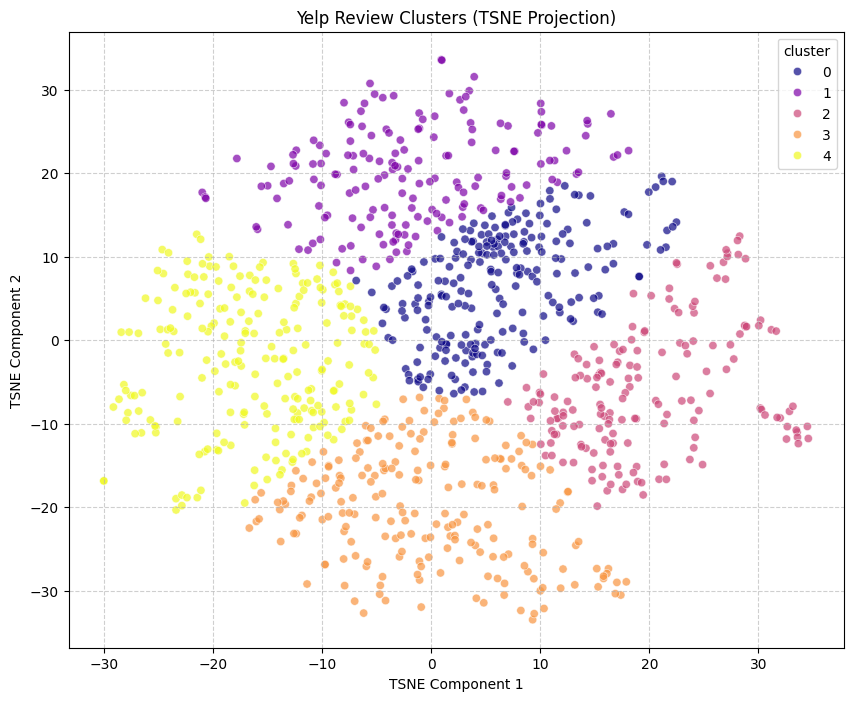

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

# Reduce dimensionality using TruncatedSVD first for TSNE performance
truncated_svd = TruncatedSVD(n_components=50, random_state=42) # Reduce to 50 dimensions
X_svd = truncated_svd.fit_transform(X_yelp)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=5000, learning_rate=250)
X_tsne = tsne.fit_transform(X_svd)

k_means = KMeans(n_clusters=5, random_state=42)
ratings['cluster'] = k_means.fit_predict(X_tsne)

# Create a DataFrame for plotting
plot_df = pd.DataFrame(data=X_tsne, columns=['TSNE1', 'TSNE2'])
plot_df['cluster'] = ratings['cluster'].values

# Plot the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE1', y='TSNE2', hue='cluster', data=plot_df, palette="plasma",
    legend='full', alpha=0.7
)
plt.title('Yelp Review Clusters (TSNE Projection)')
plt.xlabel('TSNE Component 1')
plt.ylabel('TSNE Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Conclusion

In this activity I learn how to preprocess words in a dataset by cleaning, normalizing, and removing noise to prepare text for analysis. I also learn how to create and build an LDA model, specifying the number of topics to uncover hidden themes in the reviews. Finally, I learn how to interpret the resulting topics by examining top words and sample documents, connecting them to meaningful categories for better understanding.